<a href="https://www.kaggle.com/code/mawawazir/iphone-step-counters-ratings-purchases-widgets?scriptVersionId=350976217" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 45%, #5fc9b4 80%, #f2836b 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">18 Apps &middot; US App Store &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 32px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">iPhone Step Counters: Ratings, Purchases &amp; Widgets</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
A hand-made survey of 18 step counter apps, read one listing at a time on 2026-08-17. Small enough to look at every row individually &mdash; which is exactly what this notebook does.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">18</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Apps</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">87%</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Ratings in Top 4</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">13/18</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">IAP Checked</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (deep teal -> coral)
DEEPTEAL, TEAL, MINT, CORAL, SLATE = '#0d3b3a', '#1f7a72', '#5fc9b4', '#f2836b', '#3a5a63'

df = pd.read_csv('/kaggle/input/datasets/light33/iphone-step-counter-apps-prices-and-widgets/step-counter-survey.csv')
df.shape

(18, 12)

<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">This is a small, hand-curated table — every row is worth reading, not just aggregating.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          18 non-null     object 
 1   listed_in                     18 non-null     object 
 2   ratings_count                 18 non-null     int64  
 3   rating_average                17 non-null     float64
 4   widget_per_description        18 non-null     object 
 5   reads_health_per_description  9 non-null      object 
 6   last_updated                  18 non-null     object 
 7   in_app_purchases              13 non-null     object 
 8   prices_listed                 9 non-null      object 
 9   lock_screen_per_description   18 non-null     object 
 10  kind                          9 non-null      object 
 11  app_store_id                  18 non-null     int64  
dtypes: float64(1), int64(2), object(9)
memory usage: 1.8+ KB


<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Just <b>18 rows &times; 12 columns</b>. Each row is one app's US App Store listing, hand-read on a single date. At this size, percentages and averages are descriptive, not statistical &mdash; "3 of 18 apps do X" is a fact about these 18 apps, not evidence about step-counter apps in general. This notebook treats it that way throughout.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check which fields have gaps, and what a gap actually means for this particular column.</p>
</div>


In [3]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

reads_health_per_description    9
kind                            9
prices_listed                   9
in_app_purchases                5
rating_average                  1
dtype: int64

<div style="
    border-left: 4px solid #f2836b;
    background: #fdf0ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #241713;
">
<b style="color:#c1552f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Methodology Note</b><br>
Missing here isn't uniform in meaning. <code>kind</code> is blank for any app outside the "cute" guide by design &mdash; not a data gap. <code>in_app_purchases</code> is genuinely different from that: it's <code>none</code> for 4 apps confirmed to have no purchases block, but <b>missing</b> (not <code>none</code>) for 5 more apps that were never checked for it at all. Treating those 5 as "no purchases" would be wrong &mdash; the source file's own summary says only <b>13 of 18</b> were checked.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Duplicates &amp; Label Consistency</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Confirm every app is a distinct listing and categorical fields are clean.</p>
</div>


In [4]:
print(f"Duplicate app names: {df['name'].duplicated().sum()}")
print(f"Duplicate App Store IDs: {df['app_store_id'].duplicated().sum()}")
print()
print("in_app_purchases values:", df['in_app_purchases'].unique().tolist())
print("widget_per_description values:", df['widget_per_description'].unique().tolist())

Duplicate app names: 0
Duplicate App Store IDs: 0

in_app_purchases values: ['yes', 'none', nan]
widget_per_description values: ['yes', 'no']


<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Zero duplicate apps or IDs, and the categorical fields use clean, consistent values throughout &mdash; a small file read by hand, and it shows in the tidiness of the labels.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Ratings Are Extremely Concentrated</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the actual spread of ratings_count across all 18 apps, not just its average.</p>
</div>


In [5]:
ranked = df[['name', 'ratings_count']].sort_values('ratings_count', ascending=False)
ranked

,name,ratings_count
0,StepsApp Pedometer,291037
1,Pedometer++,180123
2,Pedometer α,167598
3,Steps — Activity Tracker,131721
4,Pikmin Bloom,66956
5,Stepz,32586
6,Walkr,8008
7,Steps — Simple Pedometer,5309
8,StepDog,1267
9,Fito,500


<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The top <b>4</b> apps (StepsApp Pedometer, Pedometer++, Pedometer &alpha;, Steps &mdash; Activity Tracker) hold <b>87.0%</b> of all 885,719 ratings in this table between them. The mean ratings count (49,207) is more than <b>55&times;</b> the median (883.5) &mdash; a textbook sign that a handful of long-established apps dominate a category most other entrants are still trying to break into.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Visualizing the Concentration</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The same ranking as a log-scale bar chart, since a linear scale would flatten everything below the top 4 to invisible.</p>
</div>


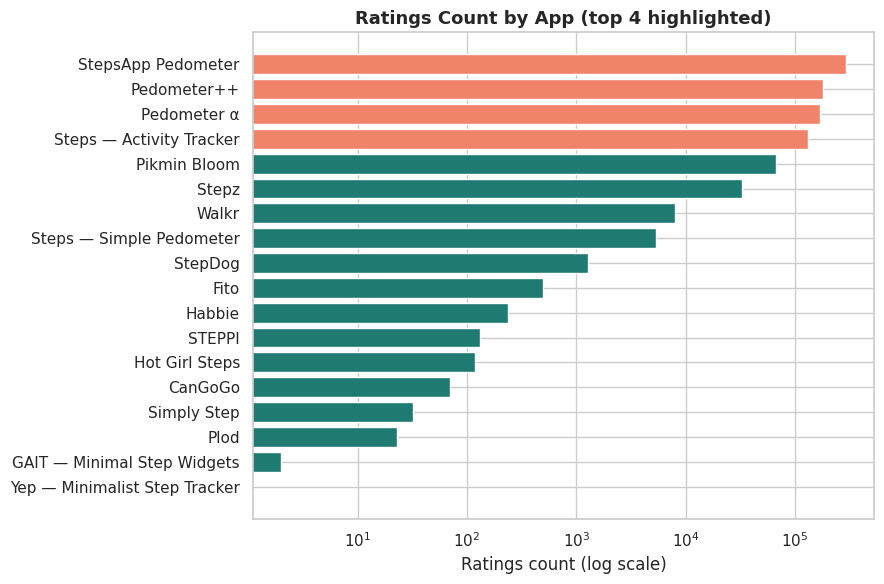

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = [CORAL if i < 4 else TEAL for i in range(len(ranked))]
ax.barh(ranked['name'][::-1], ranked['ratings_count'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Ratings count (log scale)')
ax.set_title('Ratings Count by App (top 4 highlighted)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Even on a log scale, built specifically to compress this kind of gap, the top 4 (coral) still visually dominate. On a linear scale, all 14 remaining bars would be barely distinguishable slivers next to StepsApp Pedometer's 291,037.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Small-Sample Ratings Need a Caveat</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Two apps show a perfect 5.0 average — check how many ratings that's actually built on before reading anything into it.</p>
</div>


In [7]:
df[df['ratings_count'] <= 25][['name', 'ratings_count', 'rating_average']]

,name,ratings_count,rating_average
15,Plod,23,5.0
16,GAIT — Minimal Step Widgets,2,5.0
17,Yep — Minimalist Step Tracker,0,NaN


<div style="
    border-left: 4px solid #f2836b;
    background: #fdf0ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #241713;
">
<b style="color:#c1552f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Methodology Note</b><br>
<b>Plod</b> (23 ratings) and <b>GAIT</b> (2 ratings) both show a perfect 5.0, and <b>Yep</b> has 0 ratings and no average at all. A 5.0 built on 2 reviews and a 5.0 built on 20,000 reviews are not comparable claims, even though the listing displays them identically. Any ranking or comparison by <code>rating_average</code> in this notebook excludes apps with fewer than 25 ratings for exactly this reason.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Guide Membership</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Every app is listed in at least one of the publisher's own guides — check how evenly.</p>
</div>


In [8]:
guides = df['listed_in'].str.split('; ')
all_guides = sorted({g for row in guides for g in row})
for g in all_guides:
    count = guides.apply(lambda row: g in row).sum()
    print(f"{g}: {count} of 18 apps")

cute: 9 of 18 apps
free: 13 of 18 apps
simple: 9 of 18 apps


<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
"cute" and "simple" split the 18 apps exactly evenly, <b>9 and 9</b> &mdash; a deliberate editorial structure, not a coincidence of the data. "free" cuts across both: 13 of the 18 apps are tagged free regardless of which style guide they're in.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Self-Reported Features</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Widget, lock screen, and Health mentions — all read from each listing's own description text, not verified against the app itself.</p>
</div>


In [9]:
for col in ['widget_per_description', 'lock_screen_per_description', 'reads_health_per_description']:
    counts = df[col].value_counts(dropna=False)
    print(f"{col}: {counts.to_dict()}")

widget_per_description: {'yes': 12, 'no': 6}
lock_screen_per_description: {'no': 12, 'yes': 6}
reads_health_per_description: {nan: 9, 'yes': 7, 'no': 2}


<div style="
    border-left: 4px solid #f2836b;
    background: #fdf0ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #241713;
">
<b style="color:#c1552f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Methodology Note</b><br>
Every one of these columns answers "does the listing's own text say so," not "does the app actually do this." <b>12 of 18</b> listings mention a widget and <b>6 of 18</b> mention a lock screen widget specifically. <code>reads_health_per_description</code> has 9 missing values &mdash; those are apps whose descriptions were never checked for this specific mention, not apps confirmed not to read Health data.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Second Read, A Different Date</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The lock-screen column was actually collected two days after everything else, by a different method — worth stating plainly rather than blending it in silently.</p>
</div>


In [10]:
print("Most fields: hand-read from each app's own page on 2026-08-17.")
print("lock_screen_per_description: re-read on 2026-08-19 from Apple's public listing data,")
print("matched to each app by name, rating count, and last-updated month.")
print("The source file states this second pass agreed with the hand reading in all 18 rows.")

Most fields: hand-read from each app's own page on 2026-08-17.
lock_screen_per_description: re-read on 2026-08-19 from Apple's public listing data,
matched to each app by name, rating count, and last-updated month.
The source file states this second pass agreed with the hand reading in all 18 rows.


<div style="
    border-left: 4px solid #f2836b;
    background: #fdf0ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #241713;
">
<b style="color:#c1552f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Methodology Note</b><br>
Two different collection methods, two different dates, one column. The file's own notes say the two passes agreed everywhere they overlap, which is reassuring &mdash; but it's a fact worth surfacing explicitly rather than letting all 12 columns read as if they came from one uniform process, because they didn't.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">In-App Purchases and Price Ranges</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Parse the free-text price ranges into numbers, handling the one row that has a purchases block but no listed price.</p>
</div>


In [11]:
def parse_price_range(s):
    if pd.isna(s) or 'not listed' in s:
        return pd.Series([np.nan, np.nan])
    nums = [float(n) for n in re.findall(r'[\d.]+', s)]
    return pd.Series([min(nums), max(nums)])

df[['price_low', 'price_high']] = df['prices_listed'].apply(parse_price_range)
df[df['in_app_purchases'] == 'yes'][['name', 'prices_listed', 'price_low', 'price_high']]

,name,prices_listed,price_low,price_high
0,StepsApp Pedometer,$0.99 – $19.99,0.99,19.99
1,Pedometer++,$1.99 – $39.99,1.99,39.99
3,Steps — Activity Tracker,$3.99,3.99,3.99
5,Stepz,$0.99 – $6.99,0.99,6.99
6,Walkr,$0.99 – $49.99,0.99,49.99
8,StepDog,not listed on the page we read,NaN,NaN
12,Hot Girl Steps,$4.99 – $29.99,4.99,29.99
13,CanGoGo,$0.99 – $6.99,0.99,6.99
14,Simply Step,$1.99 – $19.99,1.99,19.99


<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Of the <b>13 apps actually checked</b> for in-app purchases, <b>9 have them</b> and <b>4 don't</b> (Pedometer &alpha;, Plod, STEPPI, Steps &mdash; Simple Pedometer). Listed price ceilings range from $6.99 (Stepz, CanGoGo) up to $49.99 (Walkr). <b>StepDog</b> shows <code>in_app_purchases = yes</code> but its price range parses to nothing &mdash; the listing showed a purchases block, but the specific price text wasn't captured, and the parser correctly leaves that as missing rather than guessing zero.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Recency of Last Update</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">How current is each listing, relative to when this survey was taken?</p>
</div>


In [12]:
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}

def month_index(s):
    mon, yr = s.split()
    return int(yr) * 12 + month_map[mon]

df['month_idx'] = df['last_updated'].apply(month_index)
df.sort_values('month_idx')[['name', 'last_updated']]

,name,last_updated
8,StepDog,Aug 2025
10,Habbie,Sep 2025
16,GAIT — Minimal Step Widgets,Dec 2025
7,Steps — Simple Pedometer,Jan 2026
5,Stepz,Mar 2026
1,Pedometer++,May 2026
12,Hot Girl Steps,Jul 2026
11,STEPPI,Jul 2026
14,Simply Step,Jul 2026
15,Plod,Jul 2026


<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
8 of the 18 apps were last updated in the same month the survey was taken (Aug 2026). The three oldest listings &mdash; StepDog, Habbie, and GAIT &mdash; were last updated <b>Aug 2025</b>, <b>Sep 2025</b>, and <b>Dec 2025</b> respectively, roughly 8 to 12 months stale at the time of reading. Recency and rating count don't obviously track together here: GAIT (2 ratings) and StepsApp Pedometer (291,037 ratings) sit at opposite ends of the ratings scale while both showing recent-ish update activity.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 50%, #5fc9b4 82%, #f2836b 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Do More Ratings Come With a Richer Feature Set?</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A closing check: do the most-reviewed apps tend to claim more of these features, or is it unrelated?</p>
</div>


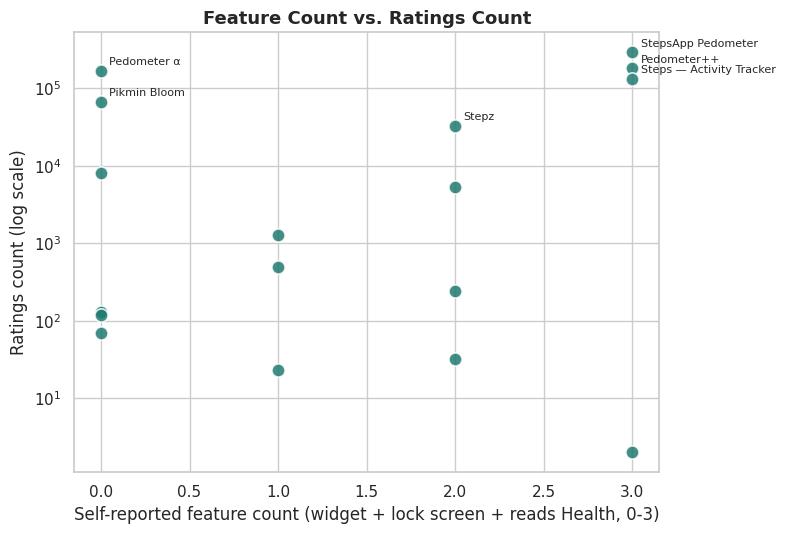

In [13]:
df['feature_count'] = (
    (df['widget_per_description'] == 'yes').astype(int) +
    (df['lock_screen_per_description'] == 'yes').astype(int) +
    (df['reads_health_per_description'] == 'yes').astype(int)
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df['feature_count'], df['ratings_count'], s=90, color=TEAL, edgecolor='white', linewidth=1.2, alpha=0.85)
for _, row in df.iterrows():
    if row['ratings_count'] > 30000:
        ax.annotate(row['name'], (row['feature_count'], row['ratings_count']), fontsize=8, xytext=(6, 4), textcoords='offset points')
ax.set_yscale('log')
ax.set_xlabel('Self-reported feature count (widget + lock screen + reads Health, 0-3)')
ax.set_ylabel('Ratings count (log scale)')
ax.set_title('Feature Count vs. Ratings Count', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #3a5a63;
    background: #eef4f4;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #17201f;
">
<b style="color:#3a5a63; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
No clean relationship. The four highest-rated apps span feature counts from 1 to 3, and several low-rated apps also claim all three features. With 18 rows and this much spread in ratings_count alone, this scatter is descriptive rather than a test of anything &mdash; it shows what these 18 apps happen to look like, not a claim that features drive ratings or vice versa.
</div>


<div style="
    background: linear-gradient(100deg, #0d3b3a 0%, #1f7a72 55%, #5fc9b4 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>This is 18 hand-read rows, not a population sample</b>: every percentage in this notebook is a fact about these specific 18 App Store listings on one date, not a general claim about step-counter apps.</li>
<li><b>Ratings are extremely concentrated</b>: the top 4 apps hold 87.0% of all ratings across the table, and the mean is 55&times; the median &mdash; a handful of established apps dominate the category.</li>
<li><b>"Missing" means different things in different columns</b>: a blank kind is a guide-membership fact, but a blank in_app_purchases means "not checked," distinct from the explicit "none" some apps show.</li>
<li><b>Every feature column reports what a listing's own text claims</b>, not a verified fact about the app &mdash; the field names say "per_description" for exactly this reason, and this notebook has kept that distinction in every section that touches them.</li>
<li><b>One column (lock screen) was collected on a different date by a different method</b> than the rest of the table; the source file reports full agreement between the two passes, which is worth stating rather than assuming.</li>
<li>The publisher of this dataset, Angel Step, makes a step counter app in the same category being surveyed; the data and its method are presented here as documented, without independent verification of any individual listing beyond what's in the source file.</li>
</ul>
</div>
